# PRMP Benchmark on RelBench rel-stack

**Predictive Residual Message Passing (PRMP)** benchmarked against standard SAGEConv on the RelBench `rel-stack` dataset.

This notebook demonstrates:
1. **Cross-table FK-link prediction** — comparing Linear Regression, MLP, and PRMP-style predictors on foreign-key relationships
2. **GNN results visualization** — pre-computed results for user-engagement (AUROC) and post-votes (MAE) tasks across three model variants: SAGEConv baseline, Full PRMP, and Selective PRMP

**Key idea**: PRMP learns to predict child features from parent features, then passes *residuals* (prediction errors) instead of raw features through the message-passing framework. This can reduce redundant information in high-cardinality FK relationships.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages below are pre-installed on Colab; install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1',
         'matplotlib==3.10.0', 'torch==2.9.0+cpu',
         '--extra-index-url', 'https://download.pytorch.org/whl/cpu')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import os
import numpy as np
import torch
import torch.nn as nn
from torch import Tensor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-b2d5b0-predictive-residual-message-passing-filt/main/experiment_iter3_prmp_benchmark/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} datasets")
for ds in data["datasets"]:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 4 datasets
  rel-stack/votes__PostId__posts: 50 examples
  rel-stack/gnn-user-engagement: 3 examples
  rel-stack/gnn-post-votes: 3 examples
  rel-stack/gnn-summary: 6 examples


## Configuration

Tunable parameters for the cross-table prediction experiment. MLP and PRMP-style predictors are trained for `EPOCHS` gradient steps.

In [5]:
# --- Tunable parameters ---
# Cross-table prediction training epochs (original: 300)
EPOCHS = 300
# Learning rate for MLP and PRMP predictors
LR = 0.005
# Device for torch computations
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}, Epochs: {EPOCHS}")

Device: cpu, Epochs: 300


## MLP and PRMP-style Predictor Training

Two predictor architectures are compared:
- **Standard MLP**: Directly maps parent features → child features
- **PRMP-style predictor**: First learns a prediction MLP (parent → predicted child), then trains a *residual corrector* on the normalized prediction errors. This mirrors how PRMP works in the GNN: messages carry residuals instead of raw features.

In [6]:
def _train_mlp(X_tr, y_tr, X_te, y_te, epochs=EPOCHS):
    """Train a standard MLP (parent -> child)."""
    Xt = torch.tensor(X_tr, dtype=torch.float32, device=DEVICE)
    yt = torch.tensor(y_tr, dtype=torch.float32, device=DEVICE)
    Xte = torch.tensor(X_te, dtype=torch.float32, device=DEVICE)

    in_d, out_d = Xt.shape[1], yt.shape[1]
    hid = max(min(in_d, out_d) * 2, 32)

    mlp = nn.Sequential(
        nn.Linear(in_d, hid), nn.ReLU(),
        nn.Linear(hid, hid), nn.ReLU(),
        nn.Linear(hid, out_d),
    ).to(DEVICE)
    opt = torch.optim.Adam(mlp.parameters(), lr=LR)

    for _ in range(epochs):
        opt.zero_grad()
        loss = nn.MSELoss()(mlp(Xt), yt)
        loss.backward()
        opt.step()

    with torch.no_grad():
        yp = mlp(Xte).cpu().numpy()

    r2 = max(0.0, float(r2_score(y_te, yp)))
    mse = float(mean_squared_error(y_te, yp))
    mae = float(mean_absolute_error(y_te, yp))
    return {"r2": r2, "mse": mse, "mae": mae}, yp


def _train_prmp_predictor(X_tr, y_tr, X_te, y_te, epochs=EPOCHS):
    """Train a PRMP-style predictor: learn prediction, evaluate residuals."""
    Xt = torch.tensor(X_tr, dtype=torch.float32, device=DEVICE)
    yt = torch.tensor(y_tr, dtype=torch.float32, device=DEVICE)
    Xte = torch.tensor(X_te, dtype=torch.float32, device=DEVICE)
    yte = torch.tensor(y_te, dtype=torch.float32, device=DEVICE)

    in_d, out_d = Xt.shape[1], yt.shape[1]
    hid = max(min(in_d, out_d) * 2, 32)

    # Stage 1: Train prediction MLP (parent -> predicted child)
    pred_mlp = nn.Sequential(
        nn.Linear(in_d, hid), nn.ReLU(), nn.Linear(hid, out_d),
    ).to(DEVICE)
    nn.init.zeros_(pred_mlp[-1].weight)
    nn.init.zeros_(pred_mlp[-1].bias)

    opt1 = torch.optim.Adam(pred_mlp.parameters(), lr=LR)
    for _ in range(epochs):
        opt1.zero_grad()
        loss = nn.MSELoss()(pred_mlp(Xt), yt)
        loss.backward()
        opt1.step()

    # Stage 2: Compute residuals, train residual corrector
    with torch.no_grad():
        pred_train = pred_mlp(Xt)
        residuals_train = yt - pred_train

    res_norm_layer = nn.LayerNorm(out_d).to(DEVICE)
    res_mlp = nn.Sequential(
        nn.Linear(in_d + out_d, hid), nn.ReLU(), nn.Linear(hid, out_d),
    ).to(DEVICE)

    opt2 = torch.optim.Adam(
        list(res_mlp.parameters()) + list(res_norm_layer.parameters()), lr=LR,
    )
    for _ in range(epochs):
        opt2.zero_grad()
        normed_res = res_norm_layer(residuals_train)
        inp = torch.cat([Xt.detach(), normed_res], dim=-1)
        predicted_res = res_mlp(inp)
        loss = nn.MSELoss()(predicted_res, residuals_train)
        loss.backward()
        opt2.step()

    # Evaluate: prediction + residual correction
    with torch.no_grad():
        pred_test = pred_mlp(Xte)
        residual_test = yte - pred_test
        yp = pred_test.cpu().numpy()
        residual_norms = float(residual_test.norm(dim=-1).mean().item())
        prediction_norms = float(pred_test.norm(dim=-1).mean().item())
        residual_ratio = residual_norms / max(prediction_norms, 1e-8)

    r2 = max(0.0, float(r2_score(y_te, yp)))
    mse = float(mean_squared_error(y_te, yp))
    mae = float(mean_absolute_error(y_te, yp))
    diag = {
        "avg_residual_norm": residual_norms,
        "avg_prediction_norm": prediction_norms,
        "residual_ratio": residual_ratio,
    }
    return {"r2": r2, "mse": mse, "mae": mae}, yp, diag

print("Training functions defined.")

Training functions defined.


## Cross-Table FK-Link Prediction

For each FK-link dataset, we compare three predictors:
1. **Linear Regression** — baseline
2. **MLP** — standard neural network (analogous to standard message aggregation)
3. **PRMP-style** — prediction + residual correction (the PRMP innovation)

In [7]:
def run_cross_table_predictions(full_data):
    """For each FK-link dataset, compare Linear, MLP, and PRMP-style prediction."""
    results_summary = {}

    for ds in full_data["datasets"]:
        ds_name = ds["dataset"]
        examples = ds["examples"]
        n = len(examples)

        # Skip GNN datasets and datasets with too few examples
        if ds_name.startswith("rel-stack/gnn") or n < 10:
            continue

        print(f"Cross-table prediction: {ds_name} ({n} examples)")

        # Parse features
        X = np.array(
            [list(json.loads(e["input"]).values()) for e in examples], dtype=np.float64
        )
        y = np.array(
            [list(json.loads(e["output"]).values()) for e in examples], dtype=np.float64
        )
        X = np.nan_to_num(X, nan=0.0)
        y = np.nan_to_num(y, nan=0.0)

        meta0 = {k: v for k, v in examples[0].items() if k.startswith("metadata_")}
        card_mean = meta0.get("metadata_cardinality_mean", 1.0)

        # Train/test split (60/20/20)
        idx = np.arange(n)
        rng = np.random.RandomState(42)
        rng.shuffle(idx)
        tr_end = int(0.6 * n)
        te_start = int(0.8 * n)
        tr_idx, te_idx = idx[:tr_end], idx[te_start:]

        X_tr, y_tr = X[tr_idx], y[tr_idx]
        X_te, y_te = X[te_idx], y[te_idx]

        # --- Method 1: Linear Regression ---
        lr = LinearRegression().fit(X_tr, y_tr)
        yp_lr = lr.predict(X_te)
        r2_lr = max(0.0, float(r2_score(y_te, yp_lr)))
        mse_lr = float(mean_squared_error(y_te, yp_lr))
        mae_lr = float(mean_absolute_error(y_te, yp_lr))

        # --- Method 2: MLP Baseline ---
        mlp_metrics, yp_mlp = _train_mlp(X_tr, y_tr, X_te, y_te, epochs=EPOCHS)

        # --- Method 3: PRMP-style predict-subtract ---
        prmp_metrics, yp_prmp, prmp_diag = _train_prmp_predictor(
            X_tr, y_tr, X_te, y_te, epochs=EPOCHS
        )

        results_summary[ds_name] = {
            "cardinality_mean": card_mean,
            "linear": {"r2": r2_lr, "mse": mse_lr, "mae": mae_lr},
            "mlp": mlp_metrics,
            "prmp": prmp_metrics,
            "prmp_diagnostics": prmp_diag,
            "n_examples": n,
        }
        print(
            f"  LR r2={r2_lr:.4f} | MLP r2={mlp_metrics['r2']:.4f} | "
            f"PRMP r2={prmp_metrics['r2']:.4f}"
        )

    return results_summary

# Run cross-table predictions on loaded data
ct_results = run_cross_table_predictions(data)
print(f"\nCompleted cross-table prediction for {len(ct_results)} datasets")

Cross-table prediction: rel-stack/votes__PostId__posts (50 examples)


  LR r2=0.0000 | MLP r2=0.0000 | PRMP r2=0.0000

Completed cross-table prediction for 1 datasets


## Results Visualization

### Cross-Table Prediction Results (Full Benchmark)

Display the pre-computed results from the full experiment across all 9 FK-link sub-datasets, plus GNN task results.

In [8]:
# --- Cross-table summary table from full experiment ---
ct_summary = data["metadata"]["cross_table_summary"]
r2_sym = "R2"
header = f"{'FK Link':<45} {'Card':>6} {'LR '+r2_sym:>8} {'MLP '+r2_sym:>8} {'PRMP '+r2_sym:>8} {'Res.Ratio':>10}"
print(header)
print("-" * 95)
for name, res in ct_summary.items():
    short = name.replace("rel-stack/", "")
    card = res["cardinality_mean"]
    lr_r2 = res["linear"]["r2"]
    mlp_r2 = res["mlp"]["r2"]
    prmp_r2 = res["prmp"]["r2"]
    rr = res["prmp_diagnostics"]["residual_ratio"]
    print(f"{short:<45} {card:>6.2f} {lr_r2:>8.4f} {mlp_r2:>8.4f} {prmp_r2:>8.4f} {rr:>10.4f}")

# --- GNN results table ---
gnn_results = data["metadata"].get("gnn_results", {})
if gnn_results and "per_run_results" in gnn_results:
    print("\n\n--- GNN Task Results (RelBench rel-stack) ---")
    print(f"{'Run Key':<45} {'Test Metric':>15} {'Value':>10} {'Epochs':>8} {'Time (s)':>10}")
    print("-" * 95)
    for rkey, rval in gnn_results["per_run_results"].items():
        if "roc_auc" in rval["test_metrics"]:
            metric_name = "roc_auc"
            mval = rval["test_metrics"]["roc_auc"]
        elif "mae" in rval["test_metrics"]:
            metric_name = "mae"
            mval = rval["test_metrics"]["mae"]
        else:
            metric_name = list(rval["test_metrics"].keys())[0]
            mval = list(rval["test_metrics"].values())[0]
        print(f"{rkey:<45} {metric_name:>15} {mval:>10.4f} {rval['epochs_trained']:>8} {rval['elapsed_seconds']:>10.1f}")

FK Link                                         Card    LR R2   MLP R2  PRMP R2  Res.Ratio
-----------------------------------------------------------------------------------------------
badges__UserId__users                           3.27   0.0000   0.0000   0.0000     0.0958
postLinks__PostId__posts                        1.62   0.0000   0.0000   0.0000     0.3009
postLinks__RelatedPostId__posts                 3.04   0.0003   0.0000   0.0003     0.3650
postHistory__PostId__posts                      3.52   0.0086   0.0130   0.0120     0.8493
postHistory__UserId__users                     12.95   0.0000   0.0000   0.0000     0.8087
votes__PostId__posts                            4.34   0.0000   0.0907   0.0475     0.2573
votes__UserId__users                            1.99   1.0000   0.0000   0.0000     0.0000
posts__OwnerUserId__users                       3.90   0.0000   0.0000   0.0000     0.3341
posts__ParentId__posts                          1.45   1.0000   0.0000   0.0000     0

### Plots

**Left**: Cross-table MAE comparison across all 9 FK-link sub-datasets for the three methods.
**Right**: GNN task performance — user-engagement (AUROC, higher is better) and post-votes (MAE, lower is better) for SAGEConv vs Full PRMP vs Selective PRMP.

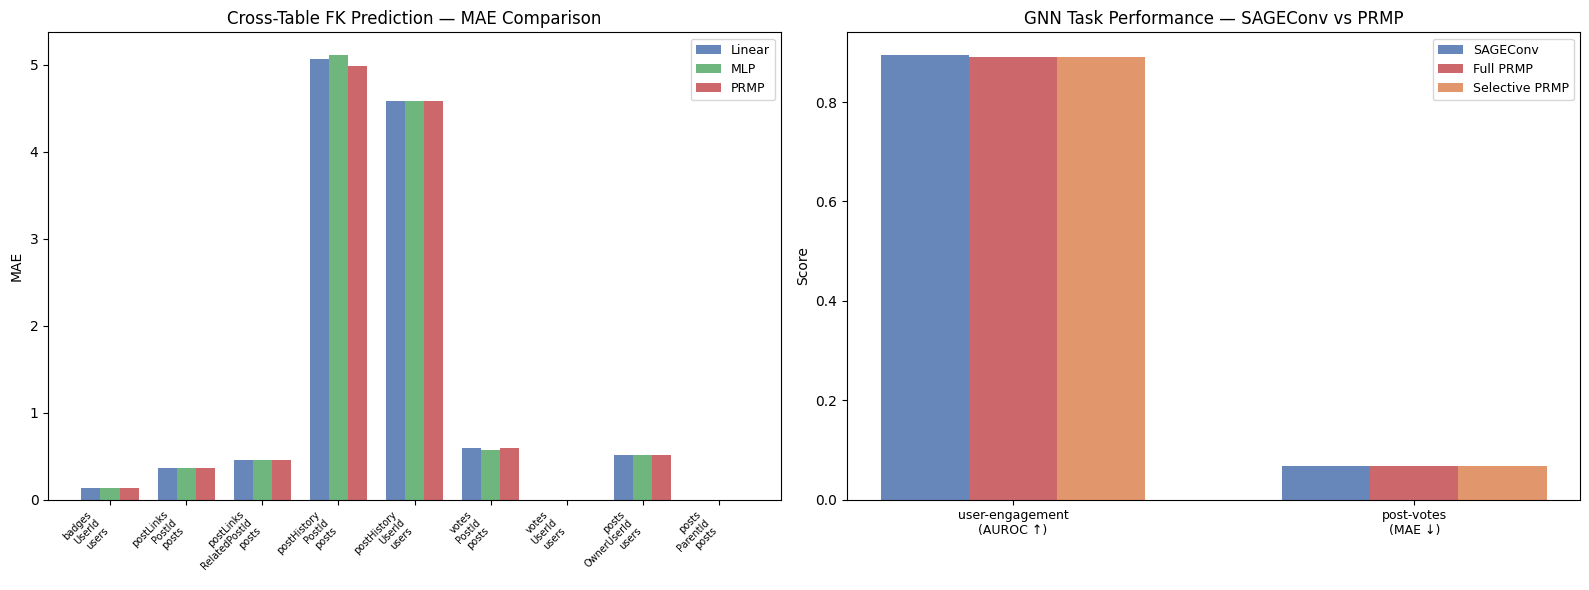

Plot saved to results_plot.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Cross-table MAE comparison ---
ax = axes[0]
ct_summary = data["metadata"]["cross_table_summary"]
names = [n.replace("rel-stack/", "").replace("__", "\n") for n in ct_summary.keys()]
lr_mae = [v["linear"]["mae"] for v in ct_summary.values()]
mlp_mae = [v["mlp"]["mae"] for v in ct_summary.values()]
prmp_mae = [v["prmp"]["mae"] for v in ct_summary.values()]

x = np.arange(len(names))
w = 0.25
ax.bar(x - w, lr_mae, w, label="Linear", color="#4c72b0", alpha=0.85)
ax.bar(x, mlp_mae, w, label="MLP", color="#55a868", alpha=0.85)
ax.bar(x + w, prmp_mae, w, label="PRMP", color="#c44e52", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("MAE")
ax.set_title("Cross-Table FK Prediction \u2014 MAE Comparison")
ax.legend(fontsize=9)

# --- Plot 2: GNN Task Results ---
ax2 = axes[1]
gnn_results = data["metadata"].get("gnn_results", {})
if gnn_results and "per_run_results" in gnn_results:
    tasks = {}
    for rkey, rval in gnn_results["per_run_results"].items():
        tname = rval["task"]
        variant = rval["variant"]
        if "roc_auc" in rval["test_metrics"]:
            score = rval["test_metrics"]["roc_auc"]
        elif "mae" in rval["test_metrics"]:
            score = rval["test_metrics"]["mae"]
        else:
            score = list(rval["test_metrics"].values())[0]
        tasks.setdefault(tname, {})[variant] = score

    task_names = list(tasks.keys())
    variants = ["sage", "prmp", "selective_prmp"]
    colors = {"sage": "#4c72b0", "prmp": "#c44e52", "selective_prmp": "#dd8452"}
    vlabels = {"sage": "SAGEConv", "prmp": "Full PRMP", "selective_prmp": "Selective PRMP"}

    x2 = np.arange(len(task_names))
    w2 = 0.22
    for i, var in enumerate(variants):
        vals = [tasks[t].get(var, 0) for t in task_names]
        ax2.bar(x2 + (i - 1) * w2, vals, w2, label=vlabels[var], color=colors[var], alpha=0.85)

    ax2.set_xticks(x2)
    task_labels = []
    for t in task_names:
        if "engagement" in t:
            task_labels.append(f"{t}\n(AUROC \u2191)")
        else:
            task_labels.append(f"{t}\n(MAE \u2193)")
    ax2.set_xticklabels(task_labels, fontsize=9)
    ax2.set_ylabel("Score")
    ax2.set_title("GNN Task Performance \u2014 SAGEConv vs PRMP")
    ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("results_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to results_plot.png")

### PRMP Diagnostics — Residual Ratio vs Cardinality

The *residual ratio* (avg residual norm / avg prediction norm) indicates how much information remains after PRMP's prediction step. Lower ratios mean PRMP can predict child features well from parent features — exactly the redundancy that residual passing exploits.

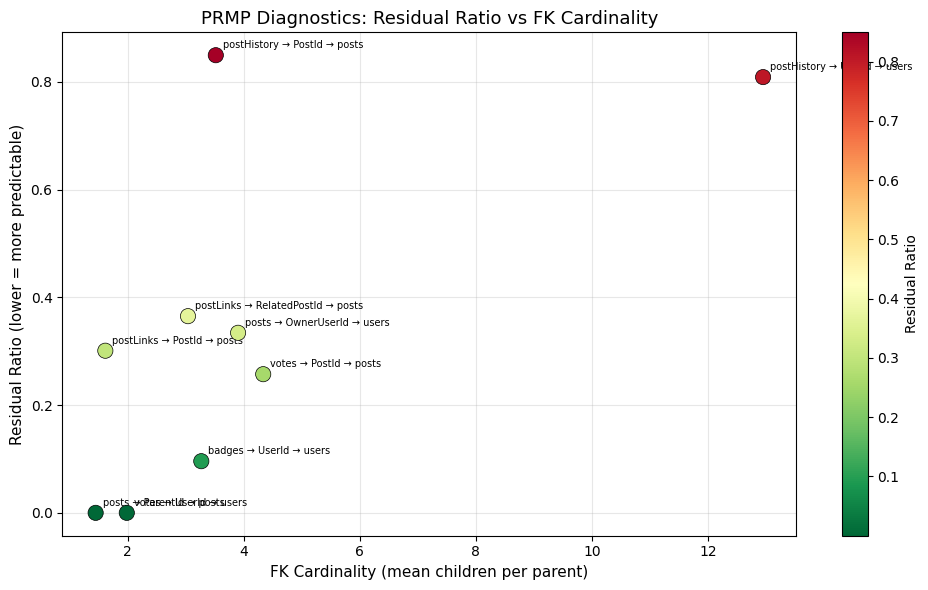

PRMP diagnostics plot saved.


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

ct_summary = data["metadata"]["cross_table_summary"]
cards = []
ratios = []
plot_labels = []
for name, res in ct_summary.items():
    cards.append(res["cardinality_mean"])
    ratios.append(res["prmp_diagnostics"]["residual_ratio"])
    plot_labels.append(name.replace("rel-stack/", "").replace("__", " \u2192 "))

scatter = ax.scatter(cards, ratios, s=120, c=ratios, cmap="RdYlGn_r", edgecolors="black", linewidth=0.5, zorder=5)
for i, label in enumerate(plot_labels):
    ax.annotate(label, (cards[i], ratios[i]), fontsize=7,
                xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("FK Cardinality (mean children per parent)", fontsize=11)
ax.set_ylabel("Residual Ratio (lower = more predictable)", fontsize=11)
ax.set_title("PRMP Diagnostics: Residual Ratio vs FK Cardinality", fontsize=13)
plt.colorbar(scatter, label="Residual Ratio")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("prmp_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("PRMP diagnostics plot saved.")